# Perception Evaluation: 2D Bounding Box IoU Calculation

In [3]:
print('hello, world')

hello, world


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

--- 自动驾驶感知评测：开始匹配 ---
✅ 预测框 1 (置信度:0.95) -> [TP/正确检测] 匹配真值框 1, IoU = 0.82
✅ 预测框 2 (置信度:0.88) -> [TP/正确检测] 匹配真值框 2, IoU = 0.63
❌ 预测框 3 (置信度:0.75) -> [FP/误检(鬼影)] 未匹配任何真值 (最大 IoU = 0.00)


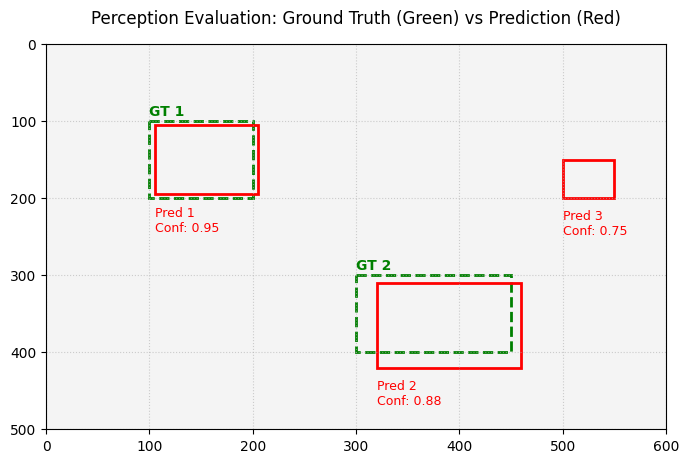

In [5]:
# ==========================================
# 步骤 1：定义核心算子 - 2D Bounding Box IoU
# ==========================================
def calculate_iou(box1, box2):
    """
    计算两个矩形框的交并比 (Intersection over Union)
    框的坐标格式设定为：[x_min, y_min, x_max, y_max]
    """
    # 1. 计算相交区域 (Intersection) 的边界
    x_left = max(box1[0], box2[0])
    y_top = max(box1[1], box2[1])
    x_right = min(box1[2], box2[2])
    y_bottom = min(box1[3], box2[3])

    # 如果没有相交，交集面积直接返回0
    if x_right < x_left or y_bottom < y_top:
        return 0.0

    intersection_area = (x_right - x_left) * (y_bottom - y_top)

    # 2. 计算两个框各自的面积
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])

    # 3. 计算并集面积 (Union)
    union_area = box1_area + box2_area - intersection_area

    # 4. 算出 IoU
    return intersection_area / union_area

# ==========================================
# 步骤 2：模拟业务数据 (Mock Data)
# ==========================================
# 模拟人工标注的真值框 (Ground Truth) - 假设图片里有两辆车
gt_boxes = [
    [100, 100, 200, 200],  # 车辆 A 的绝对正确位置
    [300, 300, 450, 400]   # 车辆 B 的绝对正确位置
]

# 模拟感知模型输出的预测框 (Prediction) 
# 格式多了一个维度: [x_min, y_min, x_max, y_max, confidence_score]
pred_boxes = [
    [105, 105, 205, 195, 0.95], # 预测框1：很准，贴合车辆 A
    [320, 310, 460, 420, 0.88], # 预测框2：有点偏差，但大体吻合车辆 B
    [500, 150, 550, 200, 0.75]  # 预测框3：无中生有，这里根本没车 (典型的误检鬼影)
]

# ==========================================
# 步骤 3：核心评测逻辑 - 匹配 TP 和 FP
# ==========================================
IOU_THRESHOLD = 0.5  # 行业通用标准：IoU大于0.5就算检测正确

print("--- 自动驾驶感知评测：开始匹配 ---")
for i, pred in enumerate(pred_boxes):
    pred_bbox = pred[:4]
    score = pred[4]      
    best_iou = 0
    best_gt_idx = -1
    
    # 将当前预测框与所有真值框计算 IoU，找出重合度最高的
    for j, gt in enumerate(gt_boxes):
        iou = calculate_iou(pred_bbox, gt)
        if iou > best_iou:
            best_iou = iou
            best_gt_idx = j
            
    # 业务判断
    if best_iou >= IOU_THRESHOLD:
        print(f"✅ 预测框 {i+1} (置信度:{score:.2f}) -> [TP/正确检测] 匹配真值框 {best_gt_idx+1}, IoU = {best_iou:.2f}")
    else:
        print(f"❌ 预测框 {i+1} (置信度:{score:.2f}) -> [FP/误检(鬼影)] 未匹配任何真值 (最大 IoU = {best_iou:.2f})")

# ==========================================
# 步骤 4：评测结果可视化 (直观分析 Badcase)
# ==========================================
fig, ax = plt.subplots(figsize=(8, 5))
ax.set_xlim(0, 600)
ax.set_ylim(500, 0) # 图像坐标系 y 轴向下
ax.set_title("Perception Evaluation: Ground Truth (Green) vs Prediction (Red)", pad=15)
ax.set_facecolor('#f4f4f4')

# 画真值 (绿色虚线)
for i, gt in enumerate(gt_boxes):
    rect = patches.Rectangle((gt[0], gt[1]), gt[2]-gt[0], gt[3]-gt[1], 
                             linewidth=2, edgecolor='green', facecolor='none', linestyle='--')
    ax.add_patch(rect)
    ax.text(gt[0], gt[1]-8, f'GT {i+1}', color='green', weight='bold')

# 画预测值 (红色实线)
for i, pred in enumerate(pred_boxes):
    rect = patches.Rectangle((pred[0], pred[1]), pred[2]-pred[0], pred[3]-pred[1], 
                             linewidth=2, edgecolor='red', facecolor='none')
    ax.add_patch(rect)
    ax.text(pred[0], pred[3]+15, f'Pred {i+1}\nConf: {pred[4]:.2f}', color='red', fontsize=9, verticalalignment='top')

plt.grid(True, linestyle=':', alpha=0.6)
plt.show()